In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import stylia
from stylia import ArticleColors, save_figure
from stylia import CategoricalPalette

stylia.set_format("slide")
stylia.set_style("ersilia")
pal = CategoricalPalette("ersilia")
nc = stylia.NamedColors()
plt.rcParams["figure.dpi"] = 300

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
pathogens = pd.read_csv(os.path.join(REPO_ROOT, "config", "pathogens.csv"))
code_to_name = dict(zip(pathogens["code"], pathogens["pathogen"]))

Pathogen: Acinetobacter baumannii
Pathogen: Candida albicans
Pathogen: Campylobacter
  [SKIP] file not found or empty: /aloy/home/acomajuncosa/Ersilia/chembl-antimicrobial-models/output/results/14_correlations/campylobacter_models.csv
Pathogen: Escherichia coli
Pathogen: Enterococcus faecium
Pathogen: Enterobacter
Pathogen: Helicobacter pylori
Pathogen: Klebsiella pneumoniae
Pathogen: Mycobacterium tuberculosis
  [SKIP] file not found or empty: /aloy/home/acomajuncosa/Ersilia/chembl-antimicrobial-models/output/results/14_correlations/mtuberculosis_models.csv
Pathogen: Neisseria gonorrhoeae
  [SKIP] file not found or empty: /aloy/home/acomajuncosa/Ersilia/chembl-antimicrobial-models/output/results/14_correlations/ngonorrhoeae_models.csv
Pathogen: Pseudomonas aeruginosa
  [SKIP] file not found or empty: /aloy/home/acomajuncosa/Ersilia/chembl-antimicrobial-models/output/results/14_correlations/paeruginosa_models.csv
Pathogen: Plasmodium falciparum
  [SKIP] file not found or empty: /aloy/h

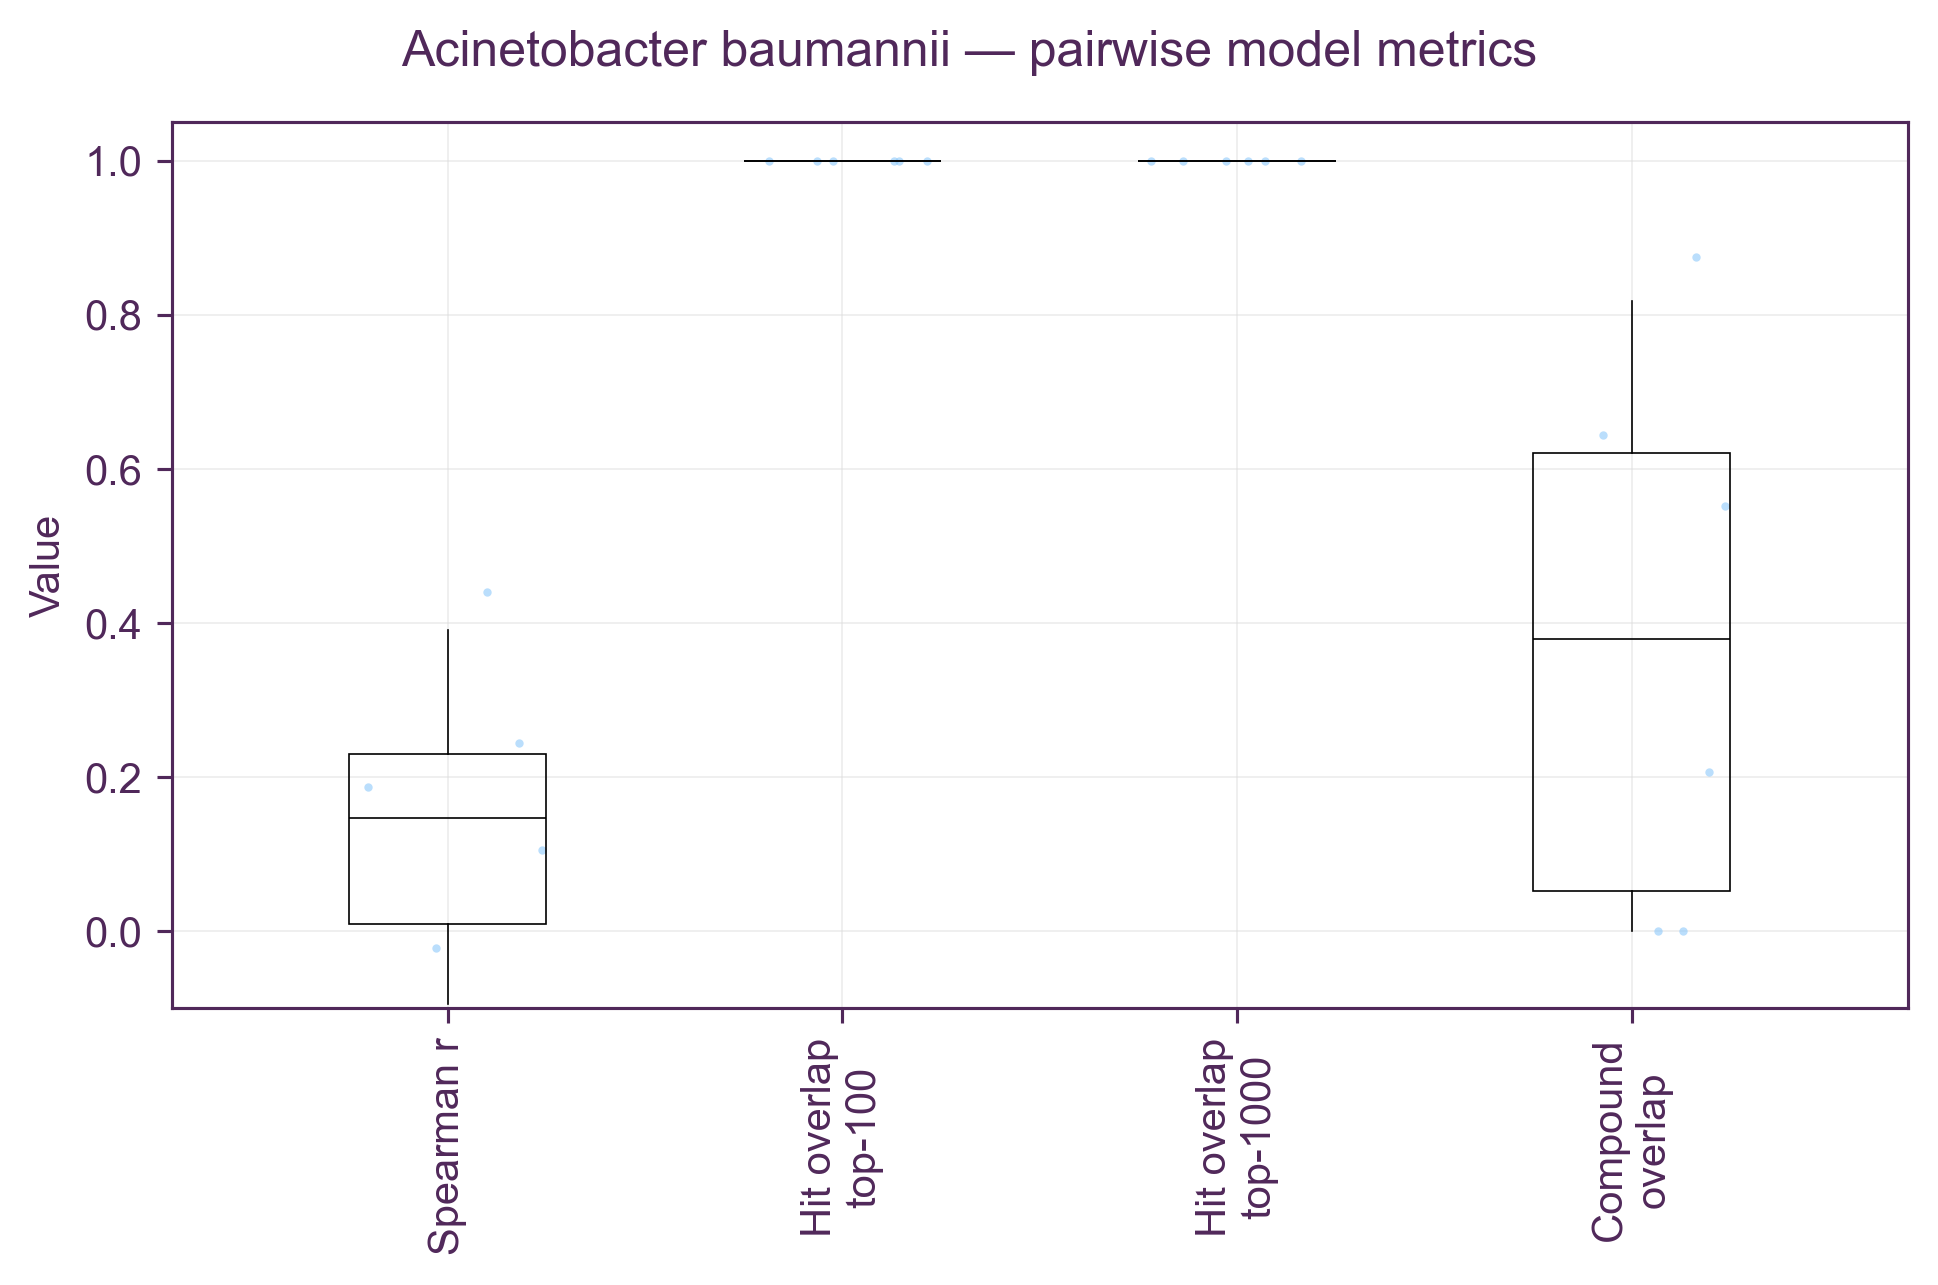

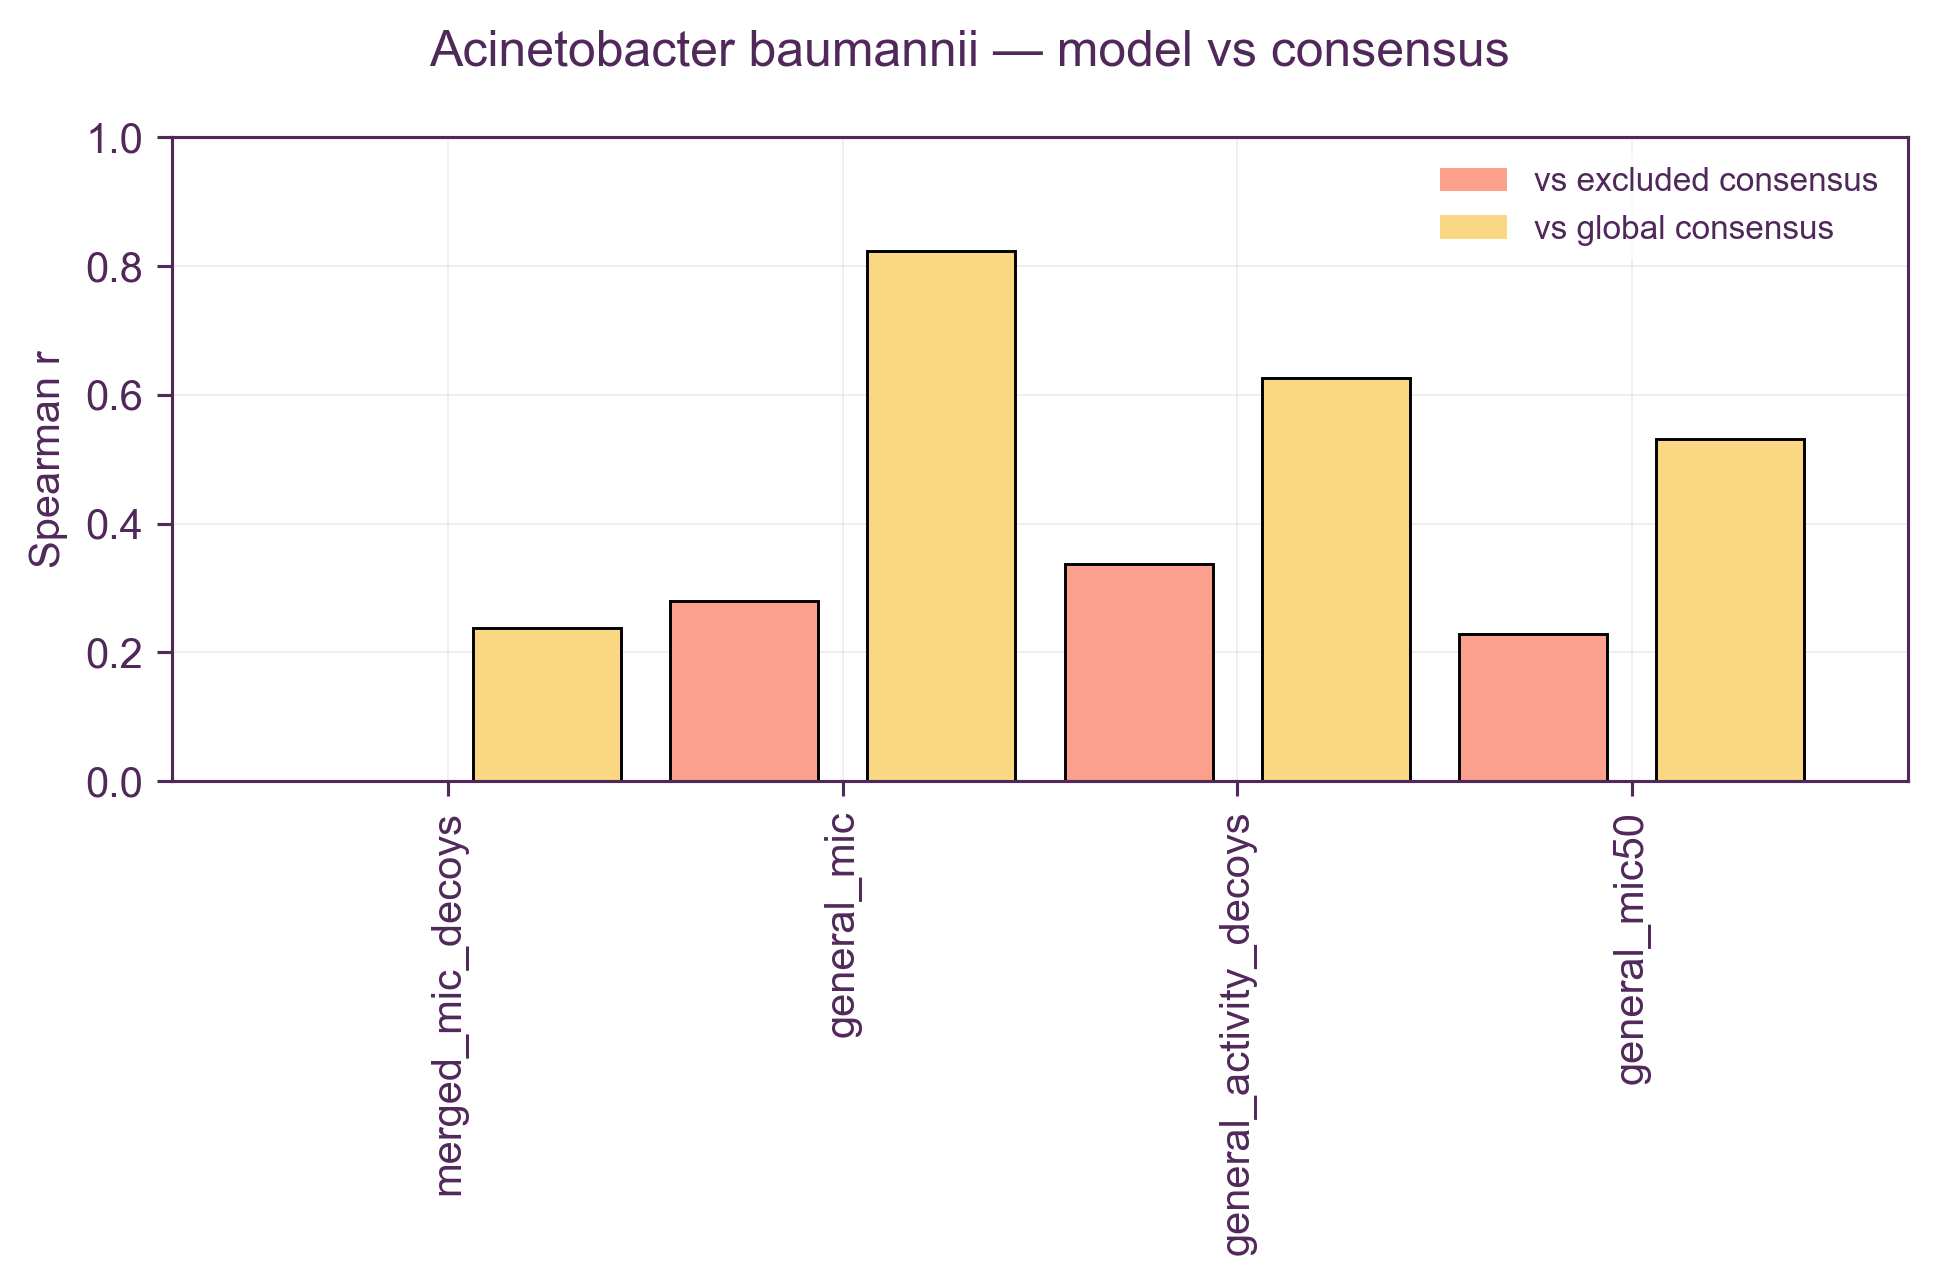

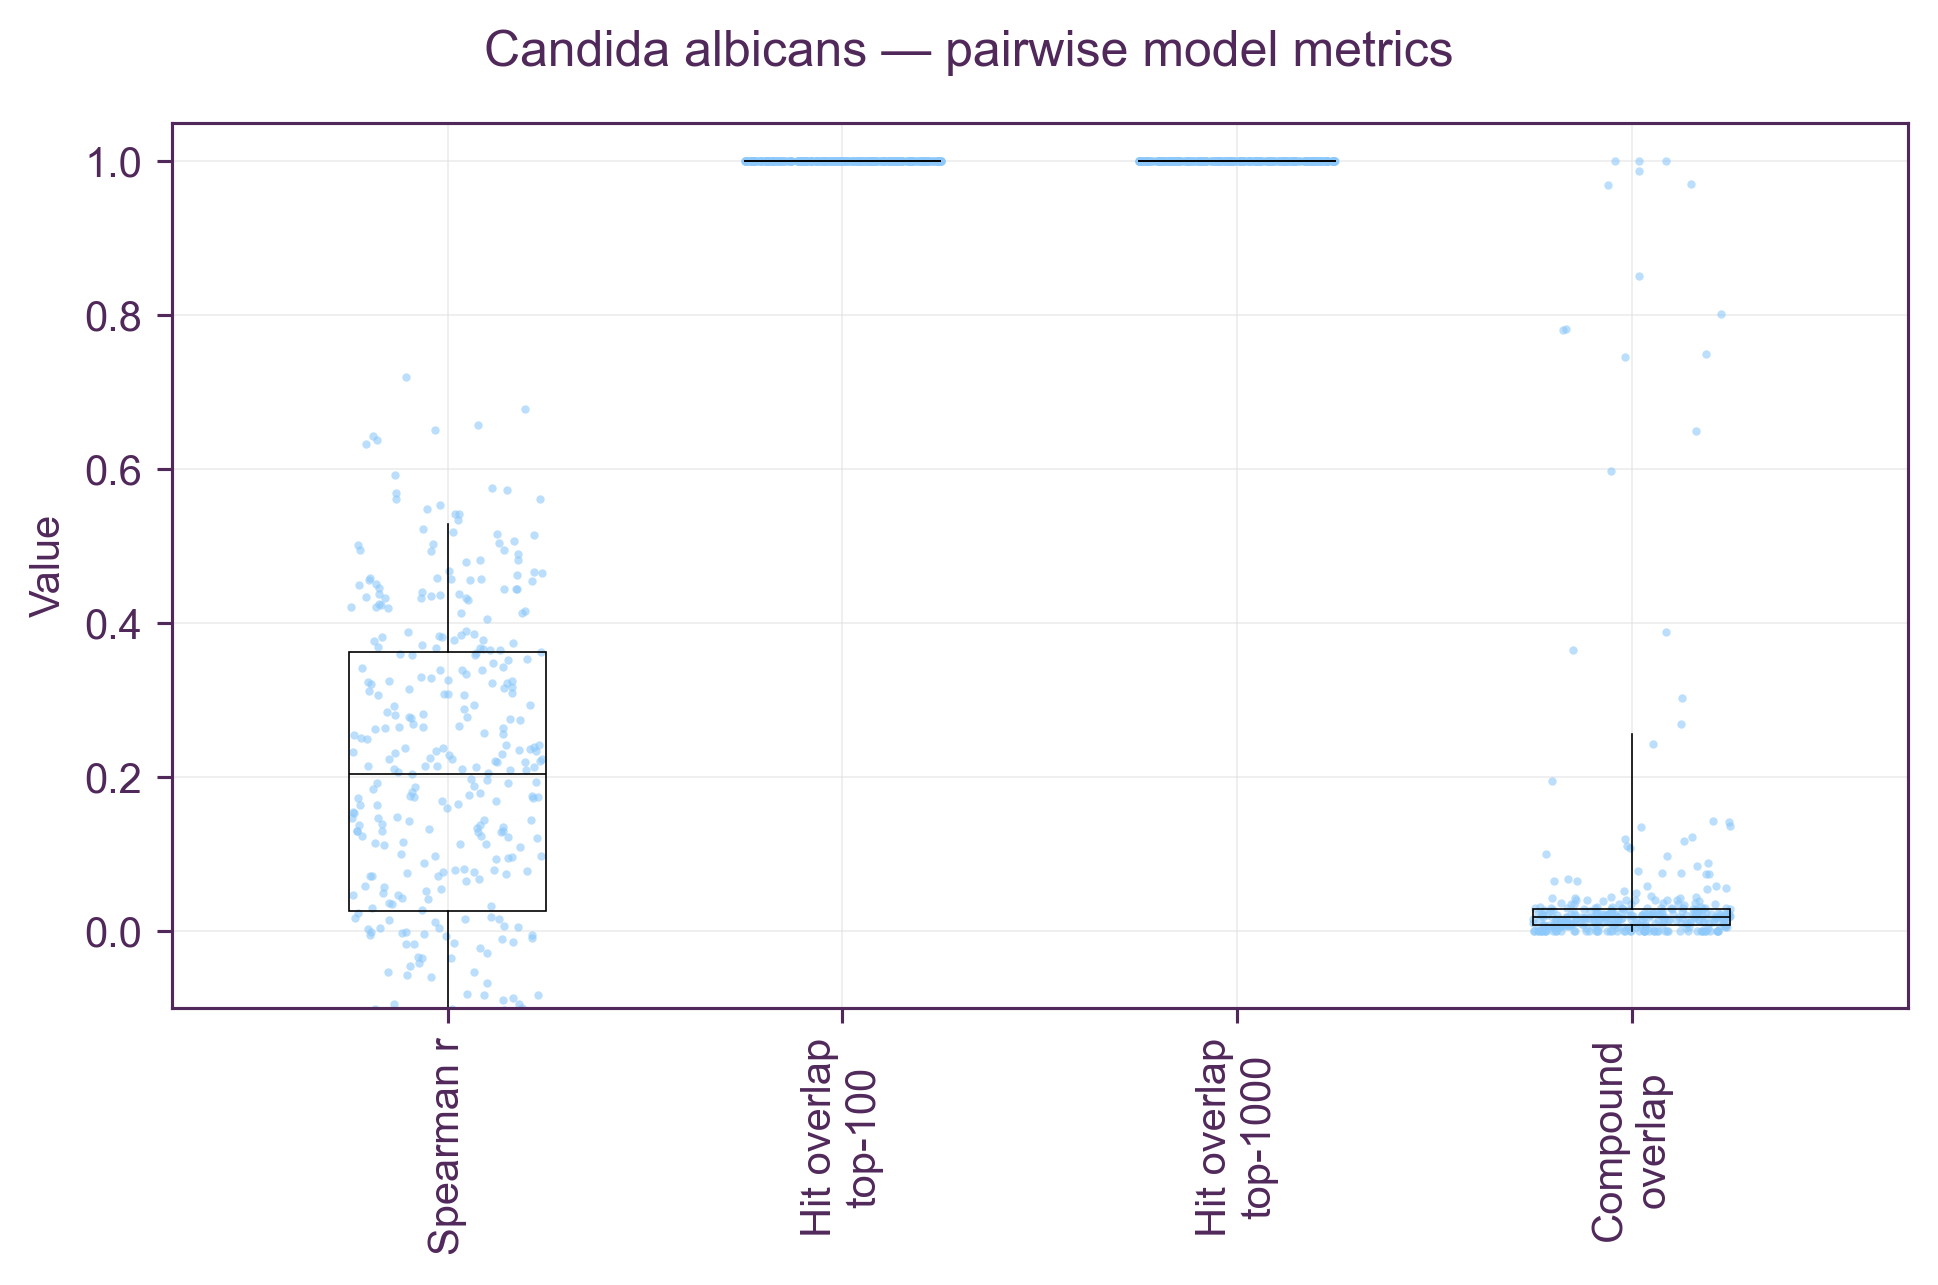

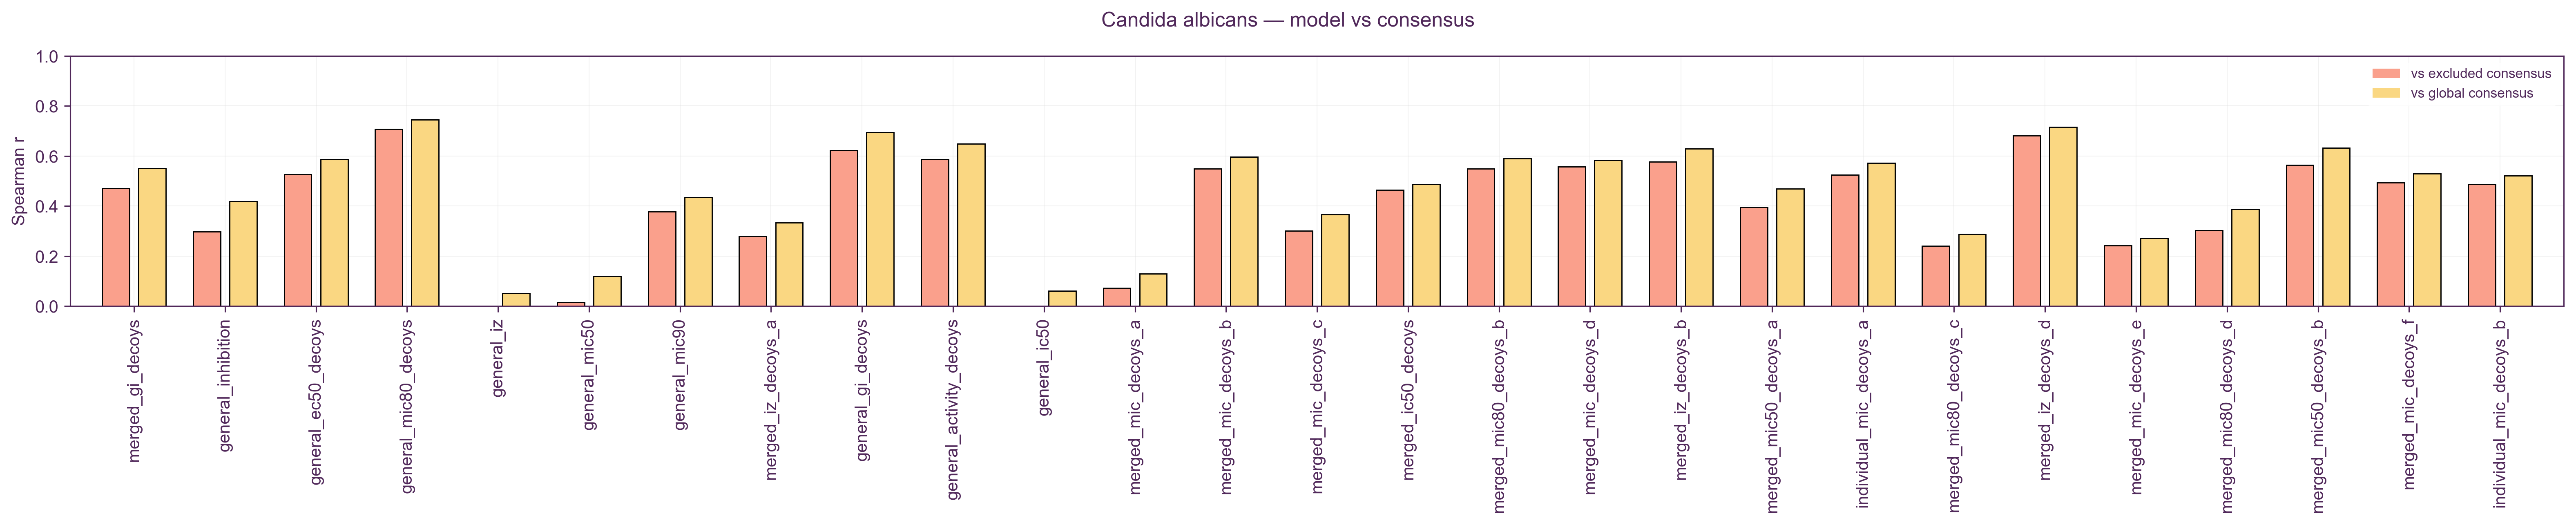

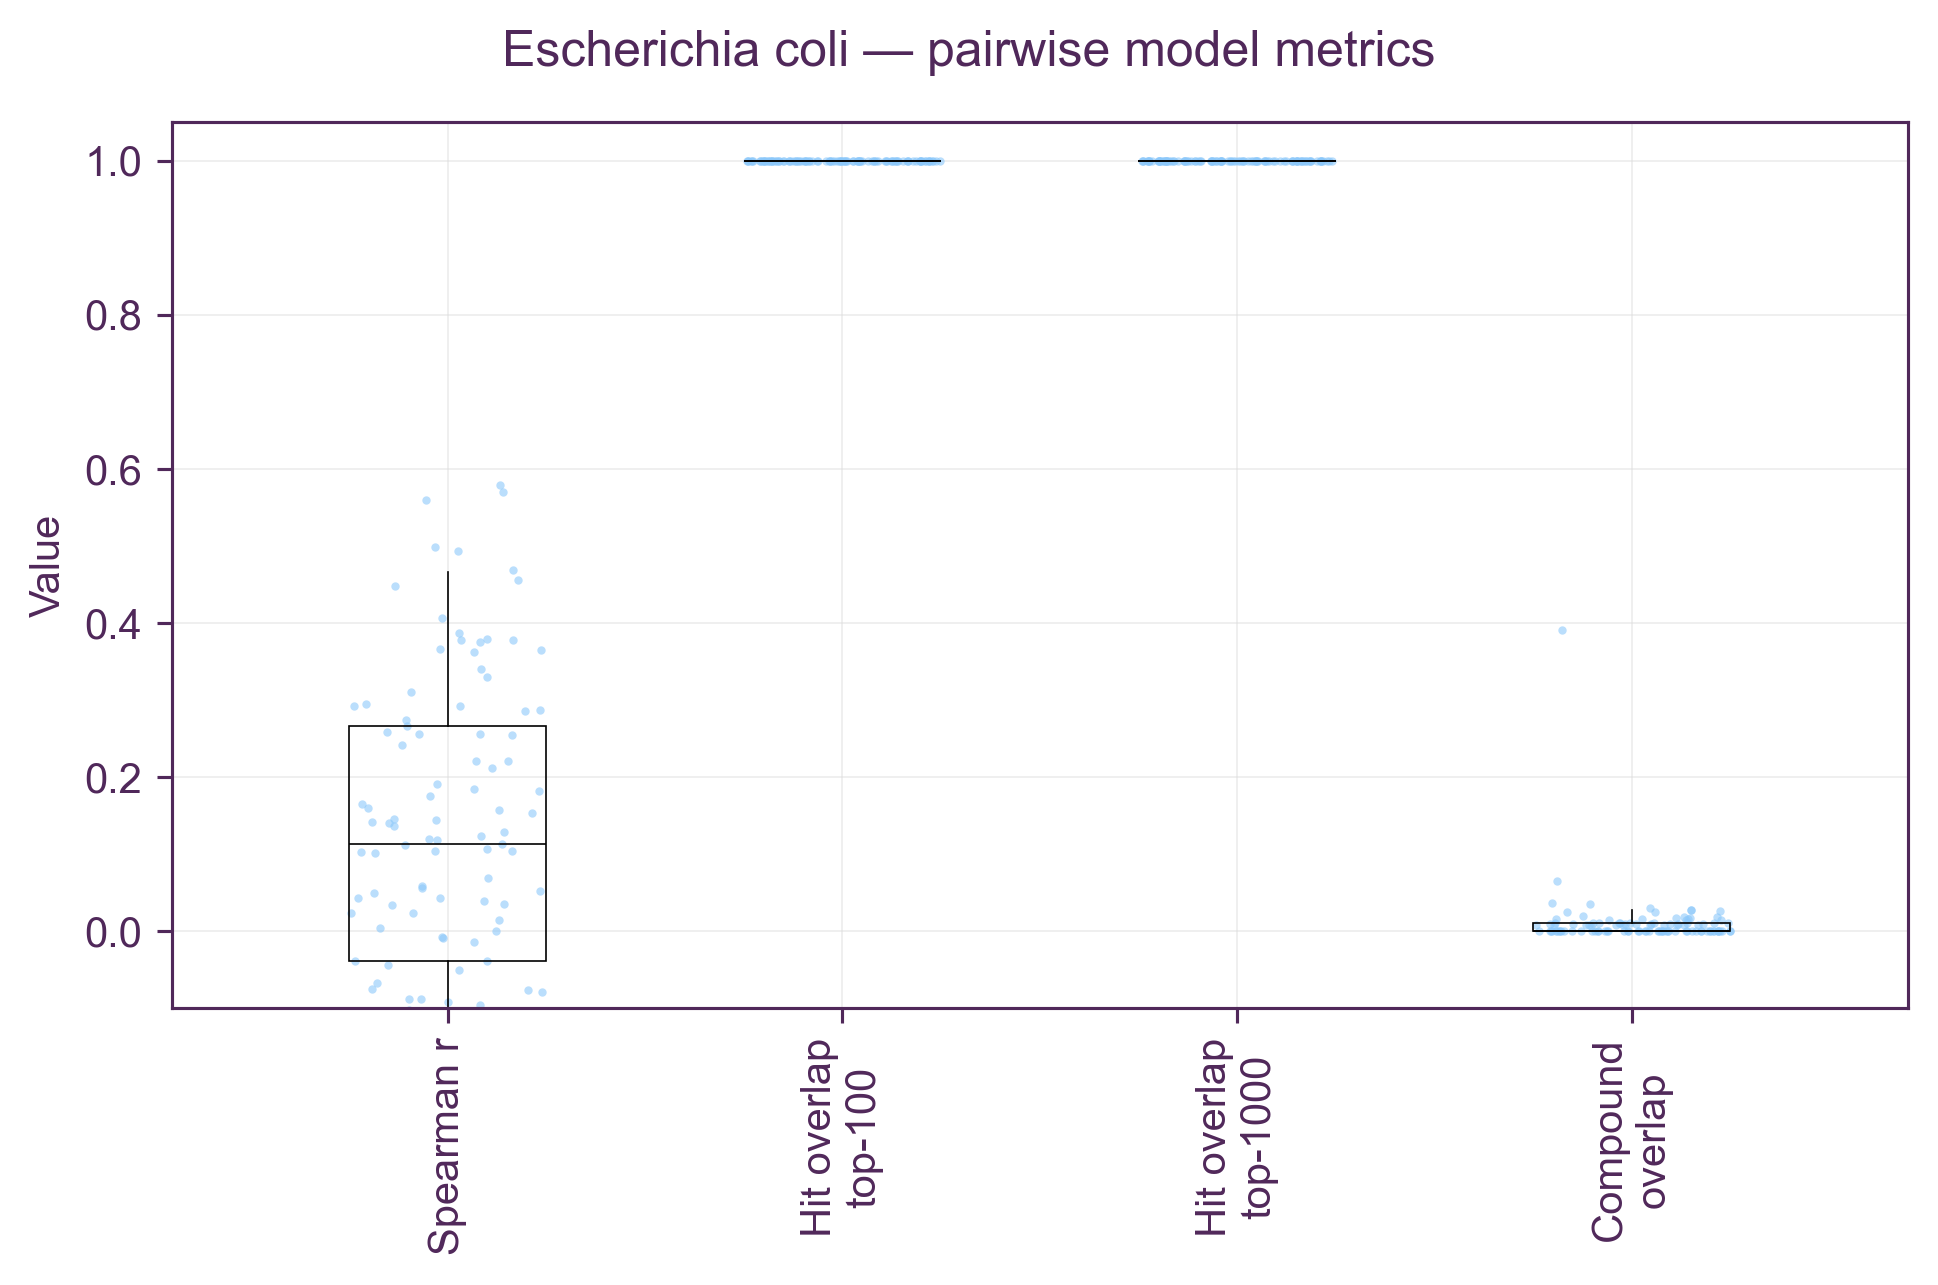

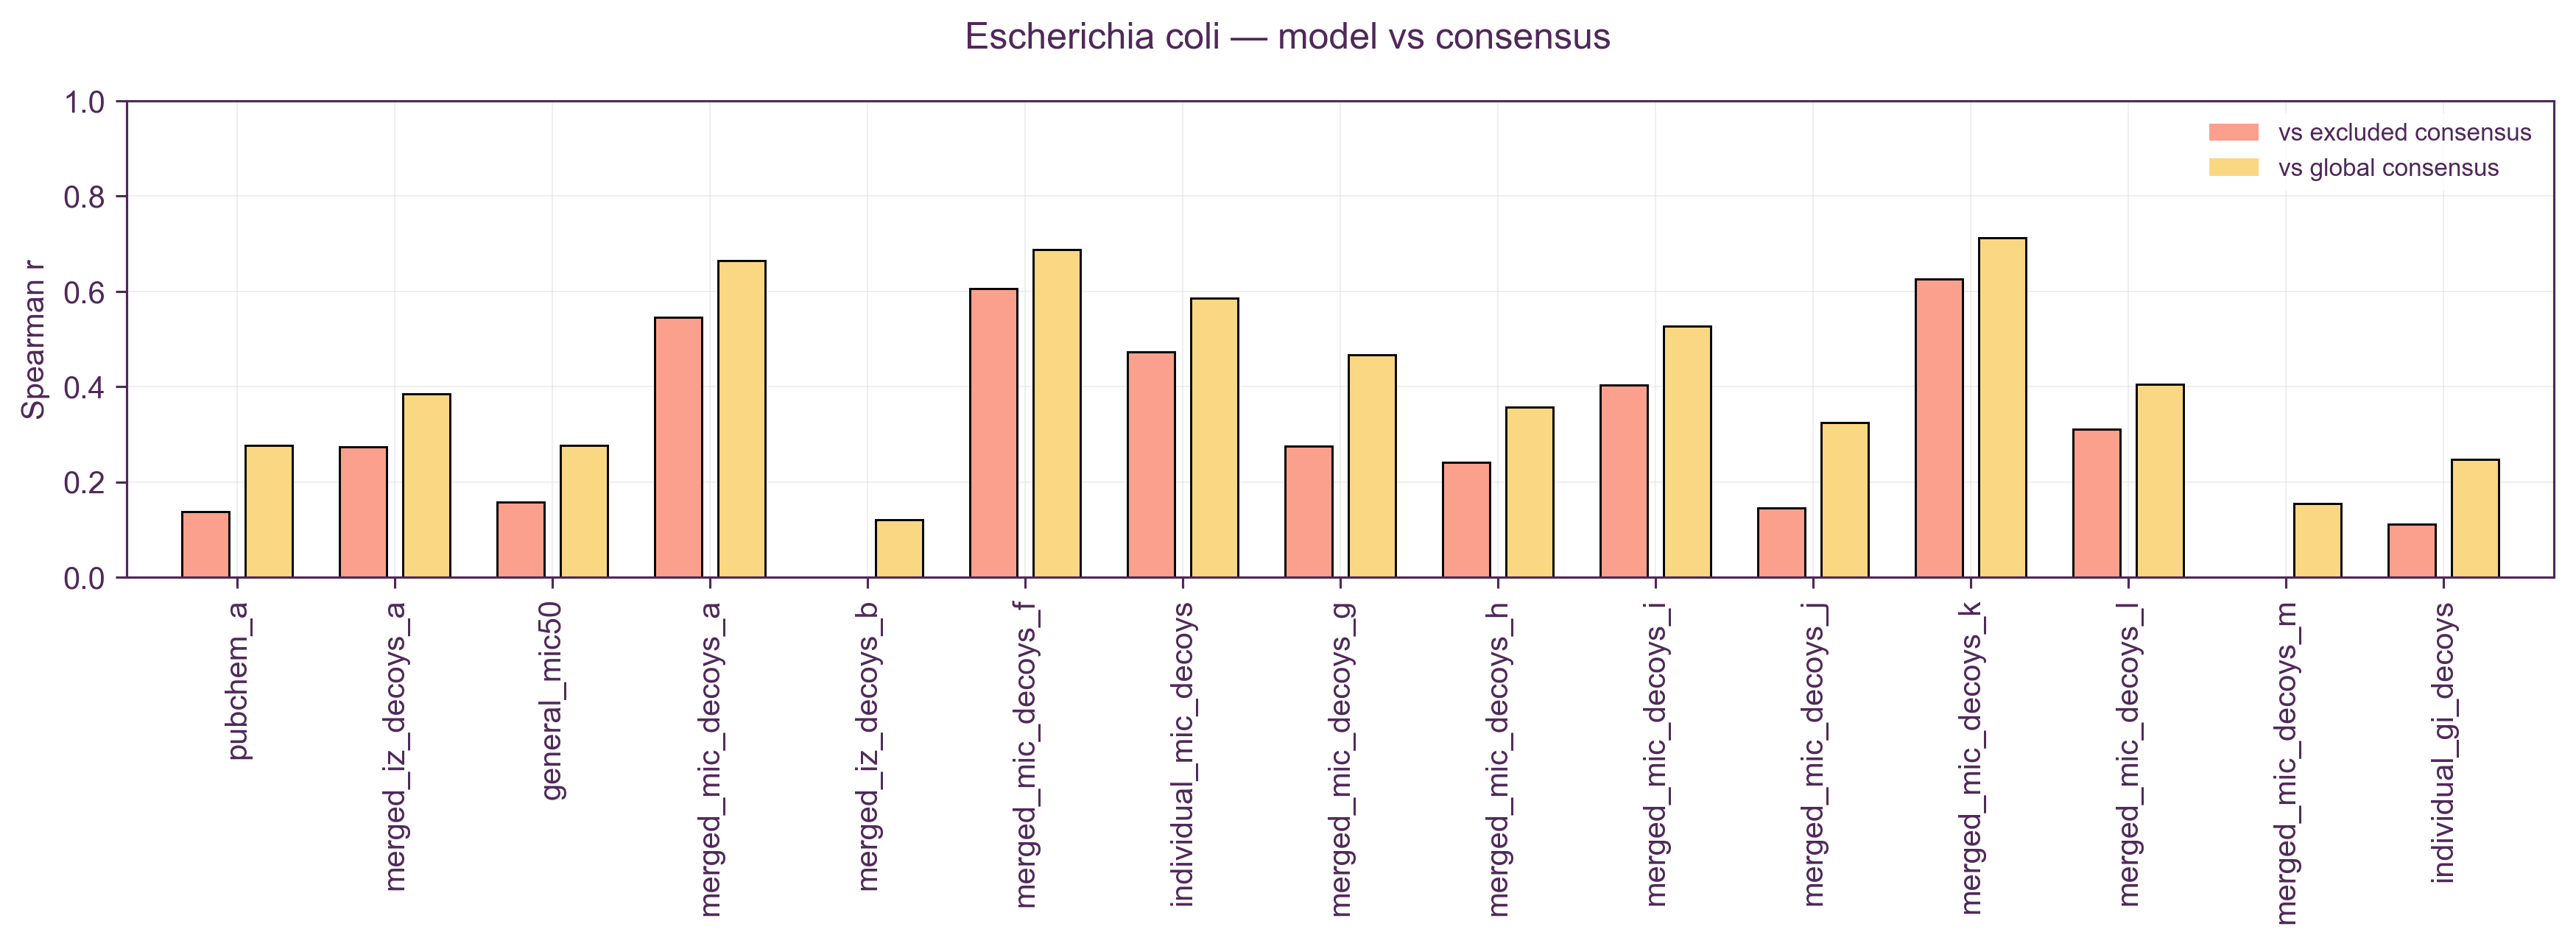

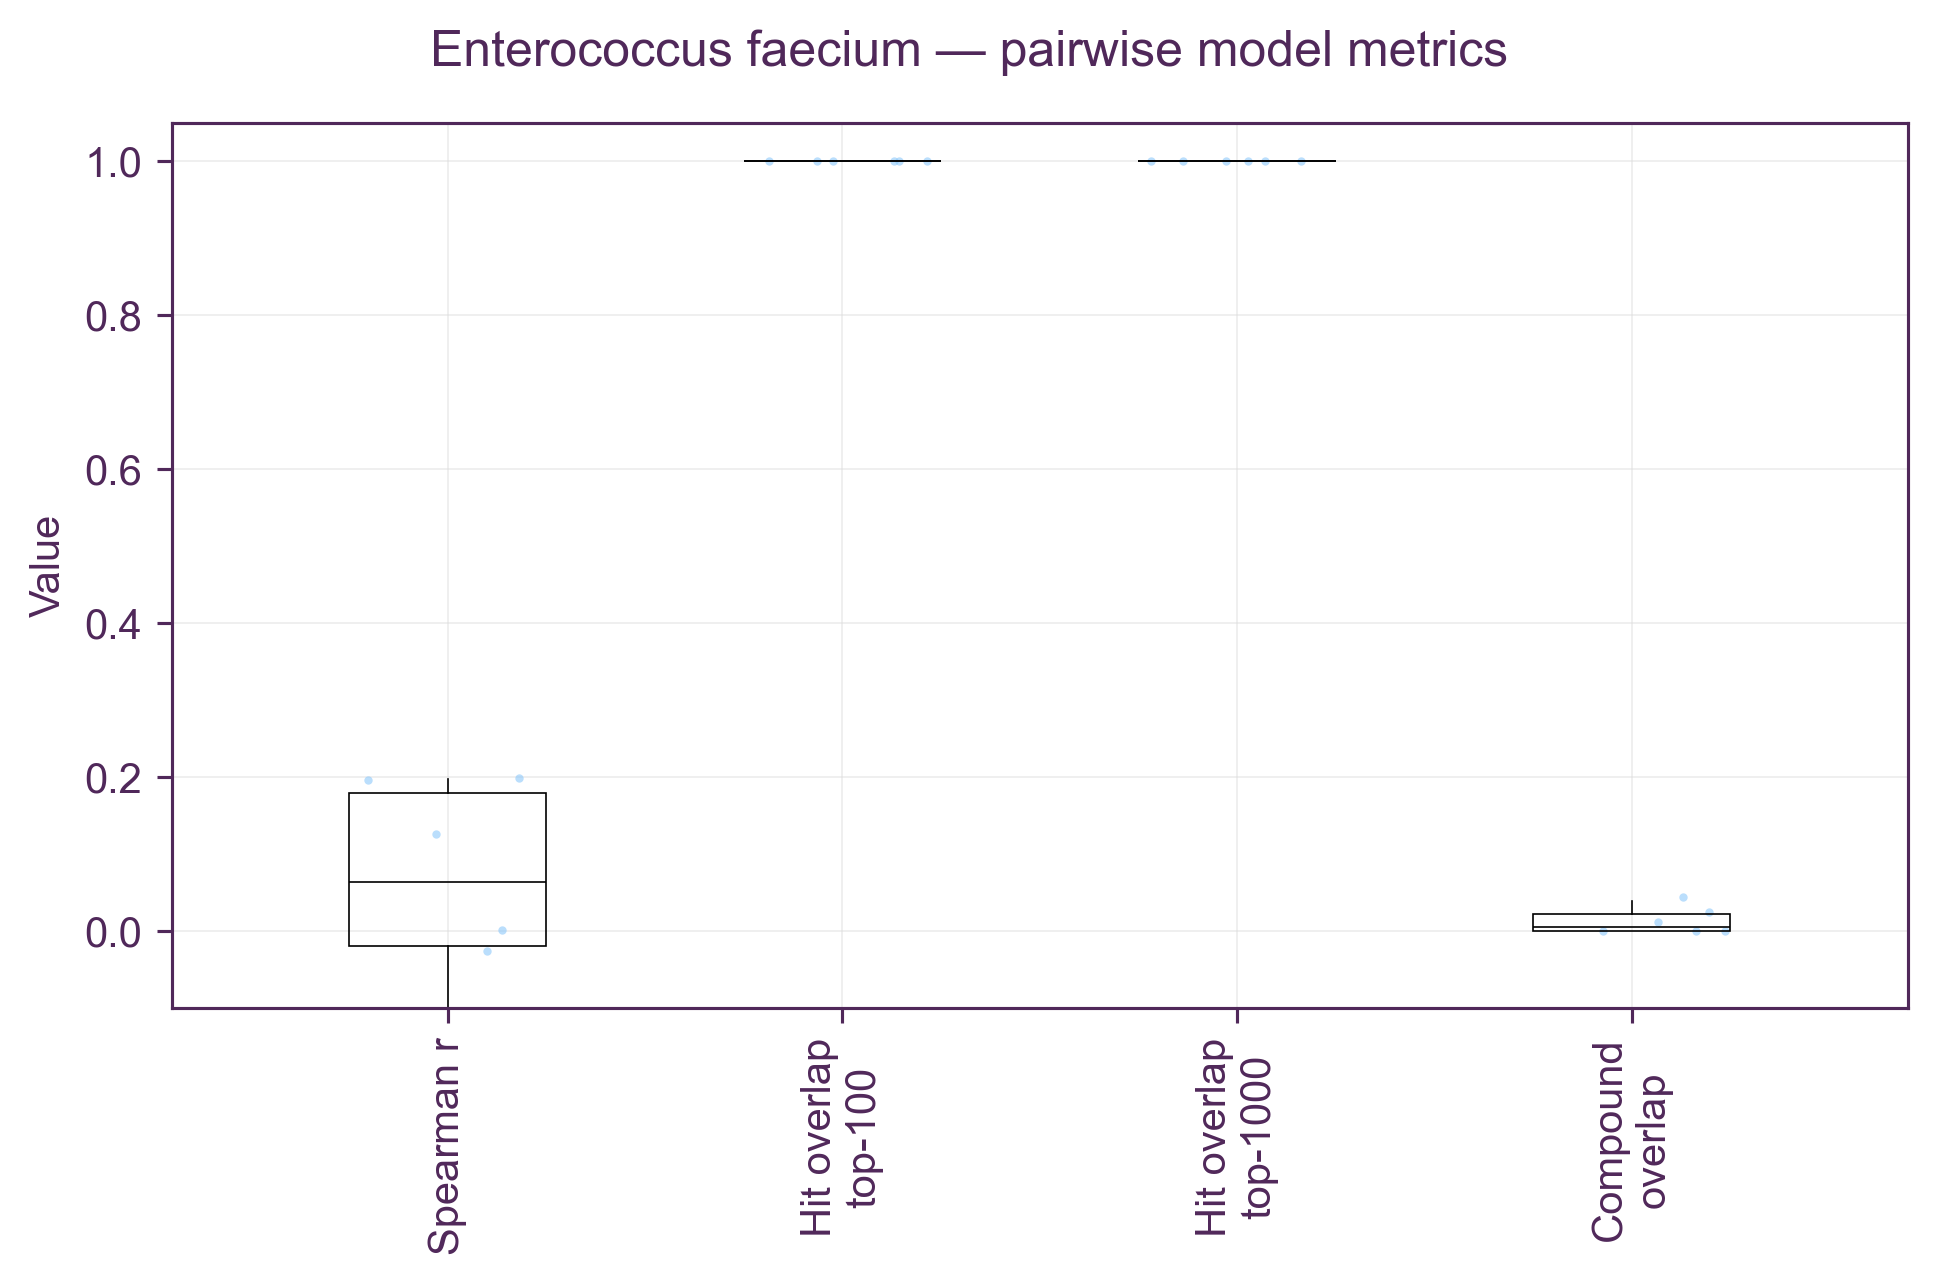

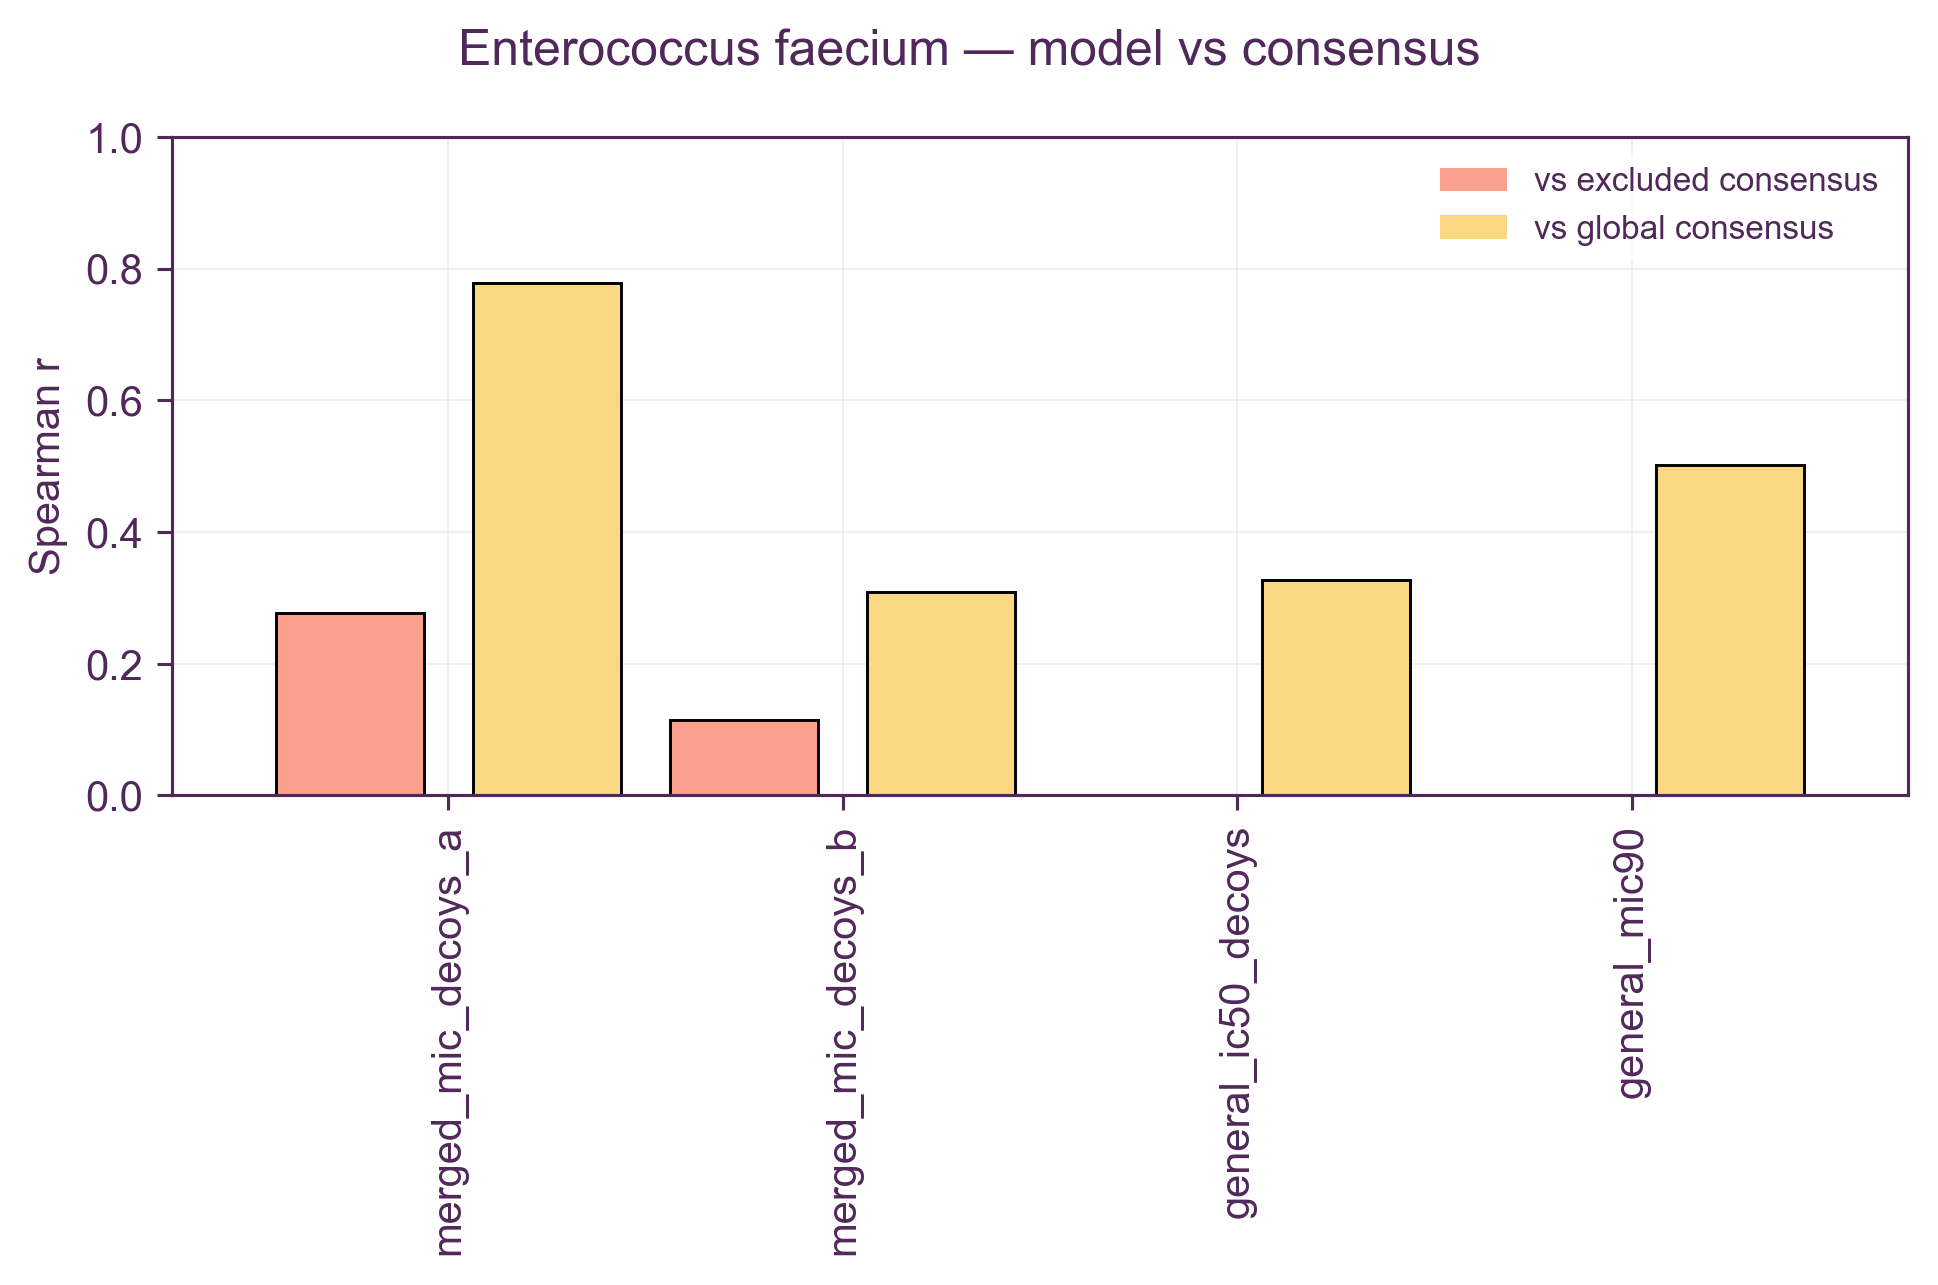

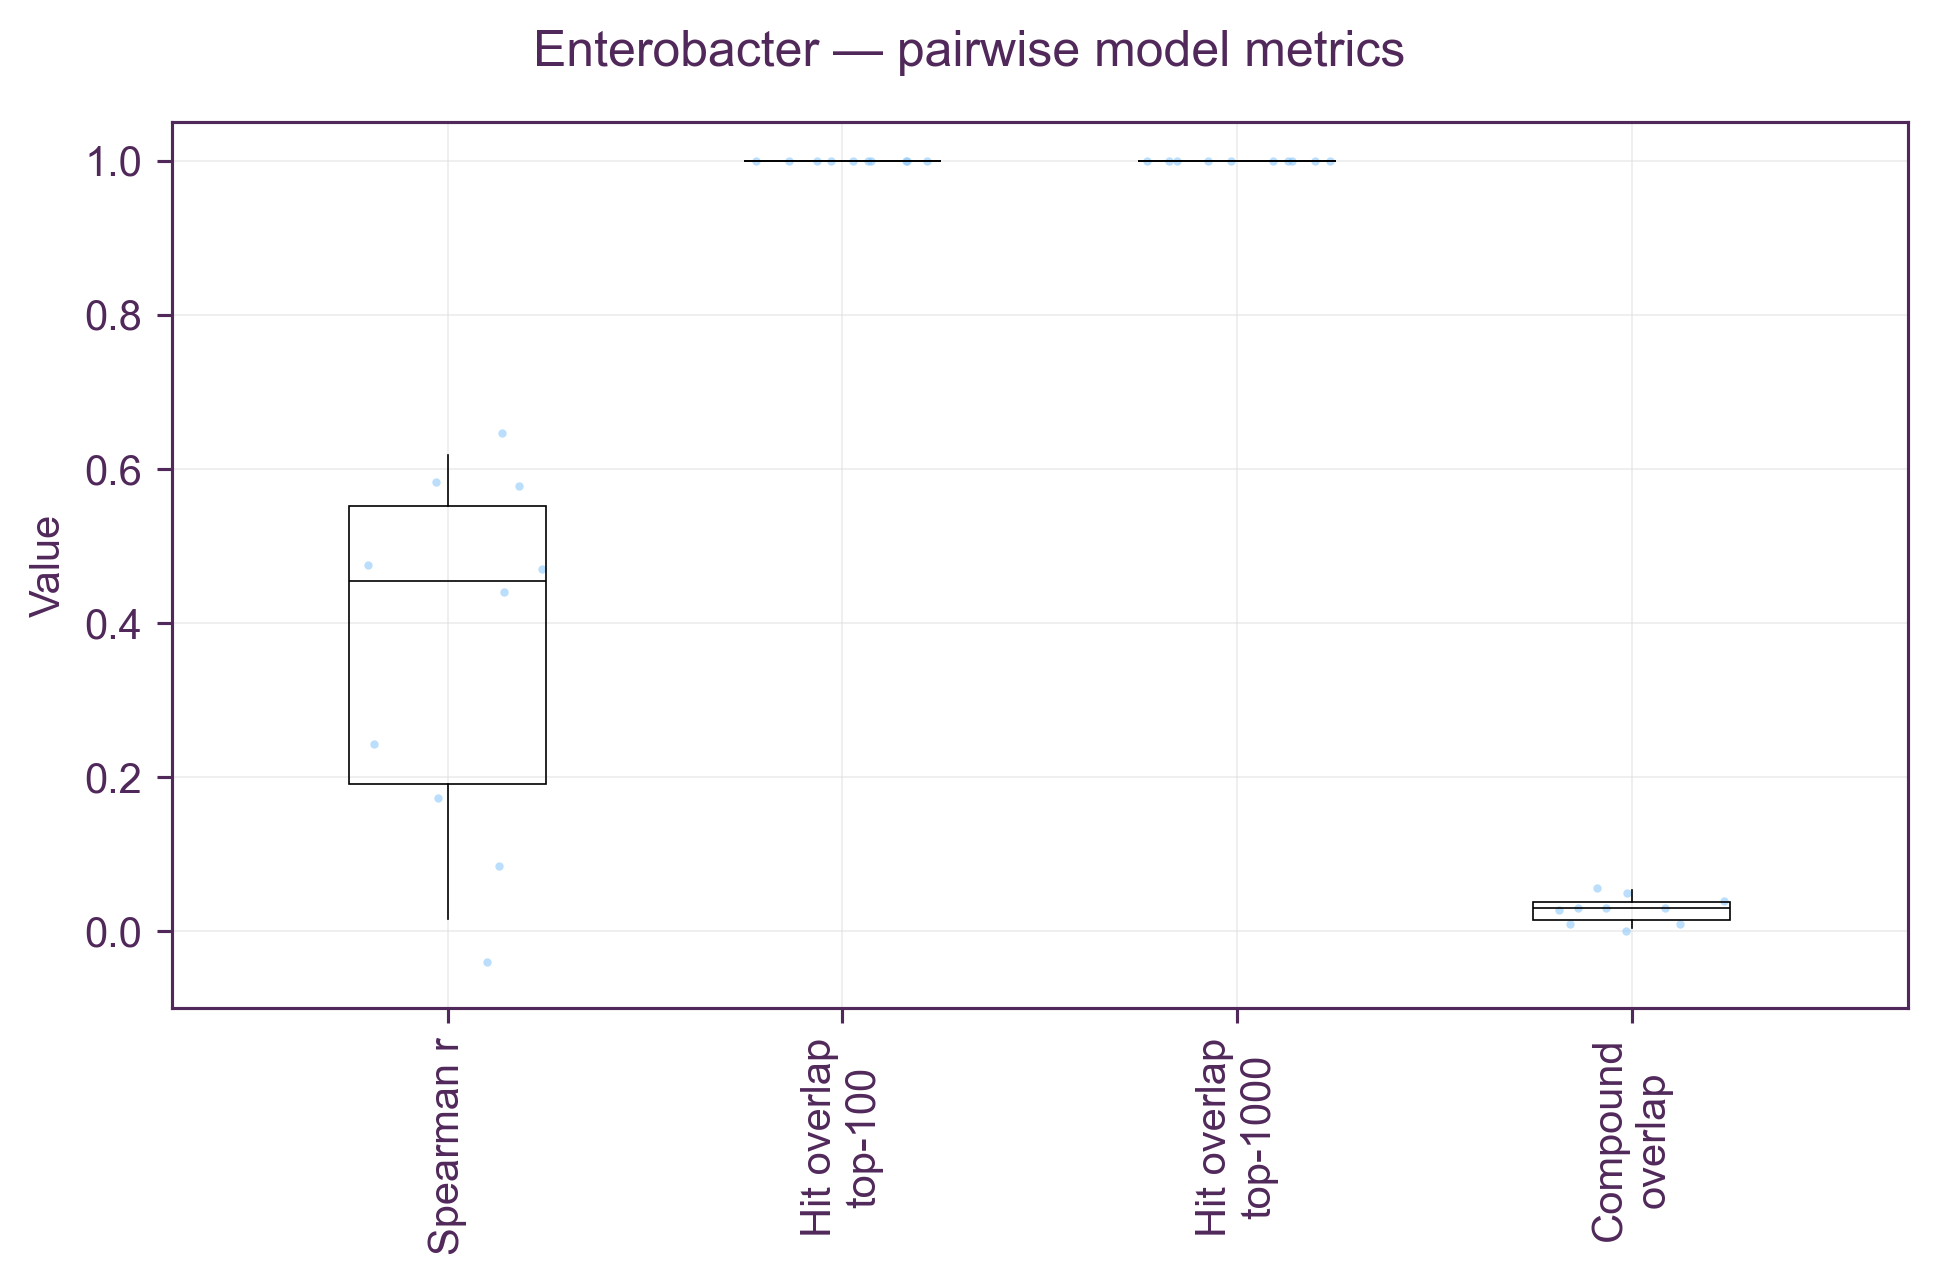

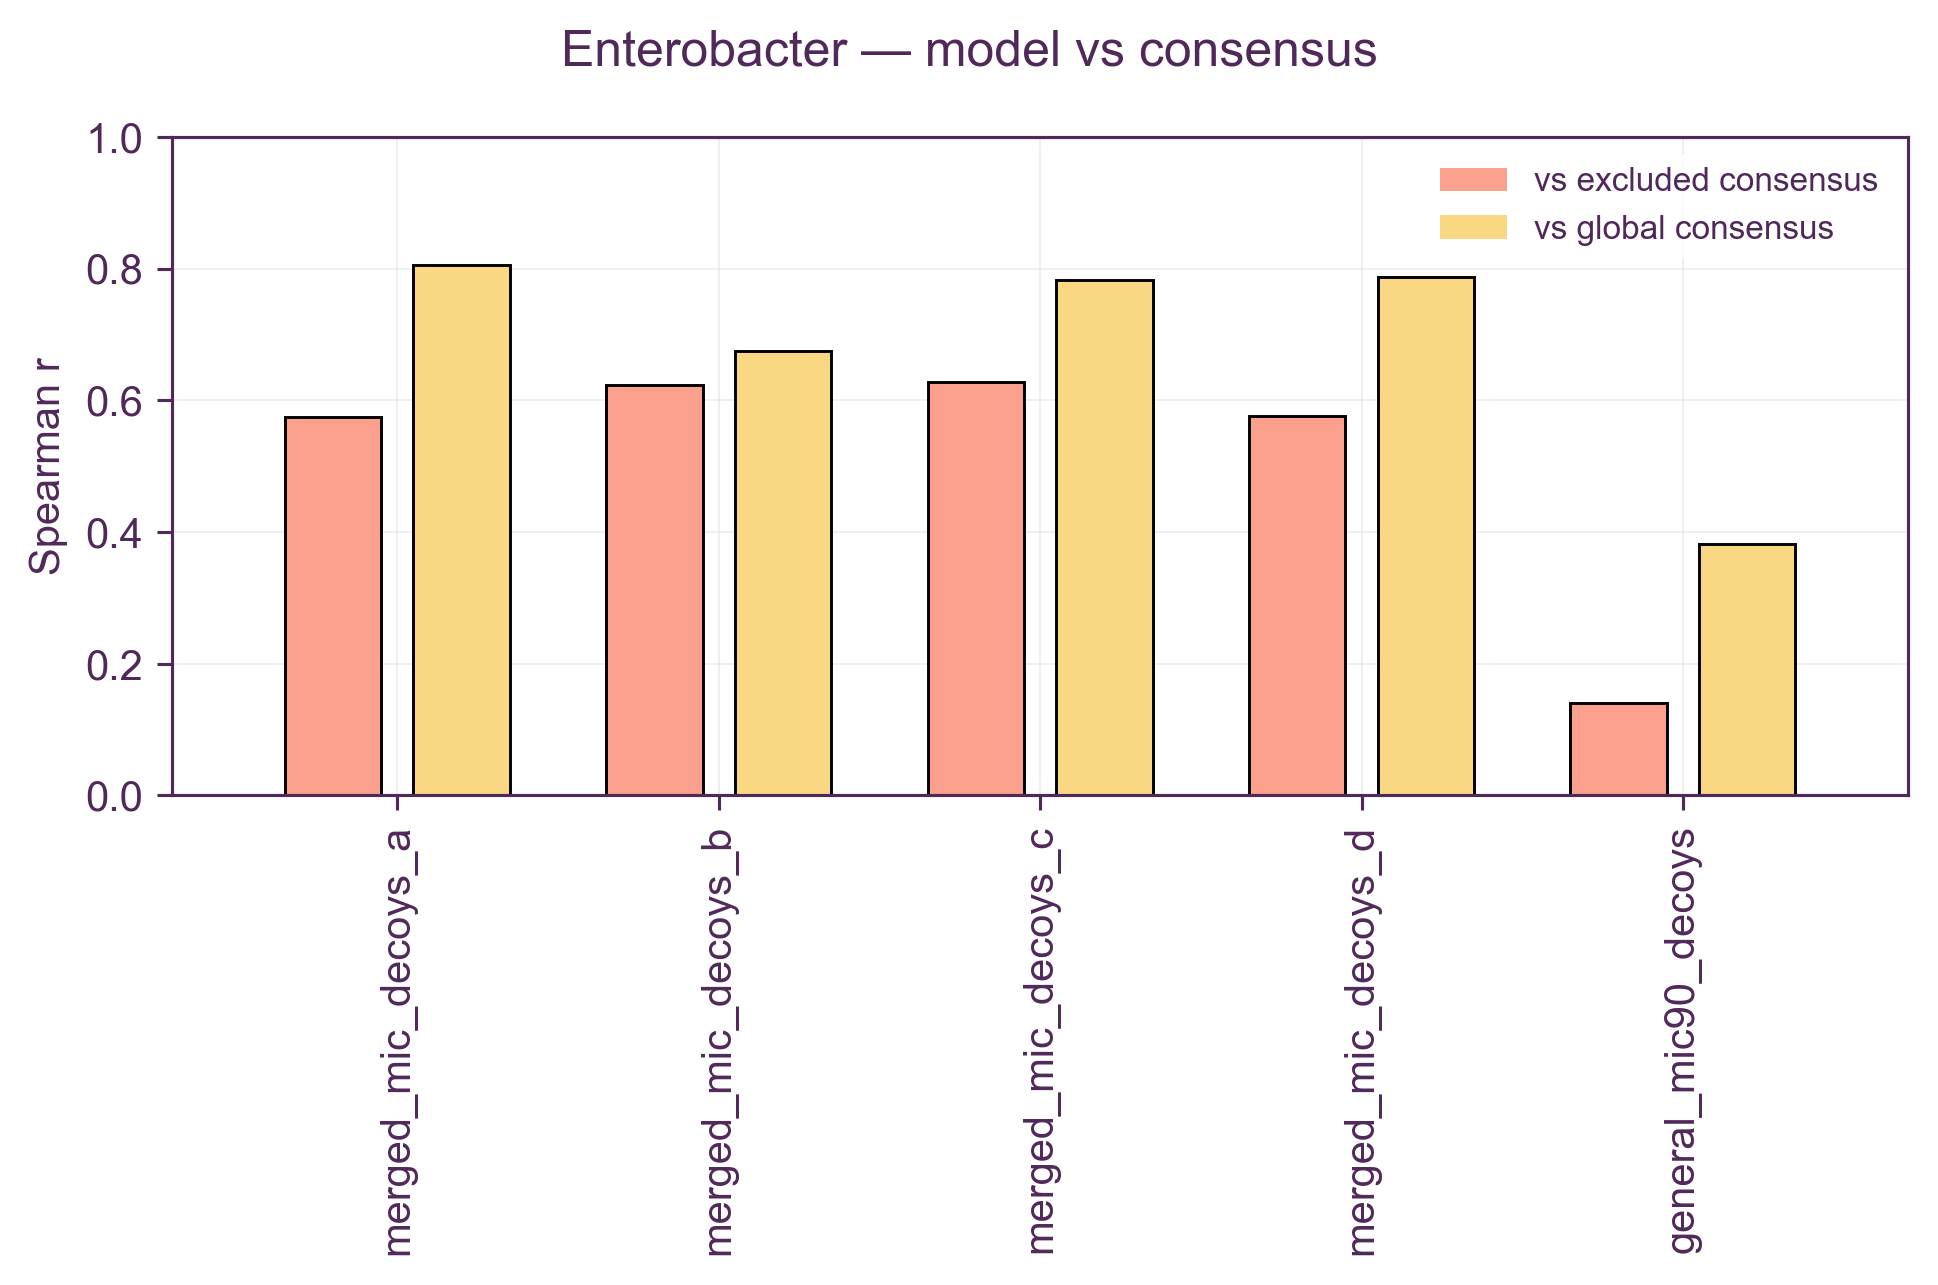

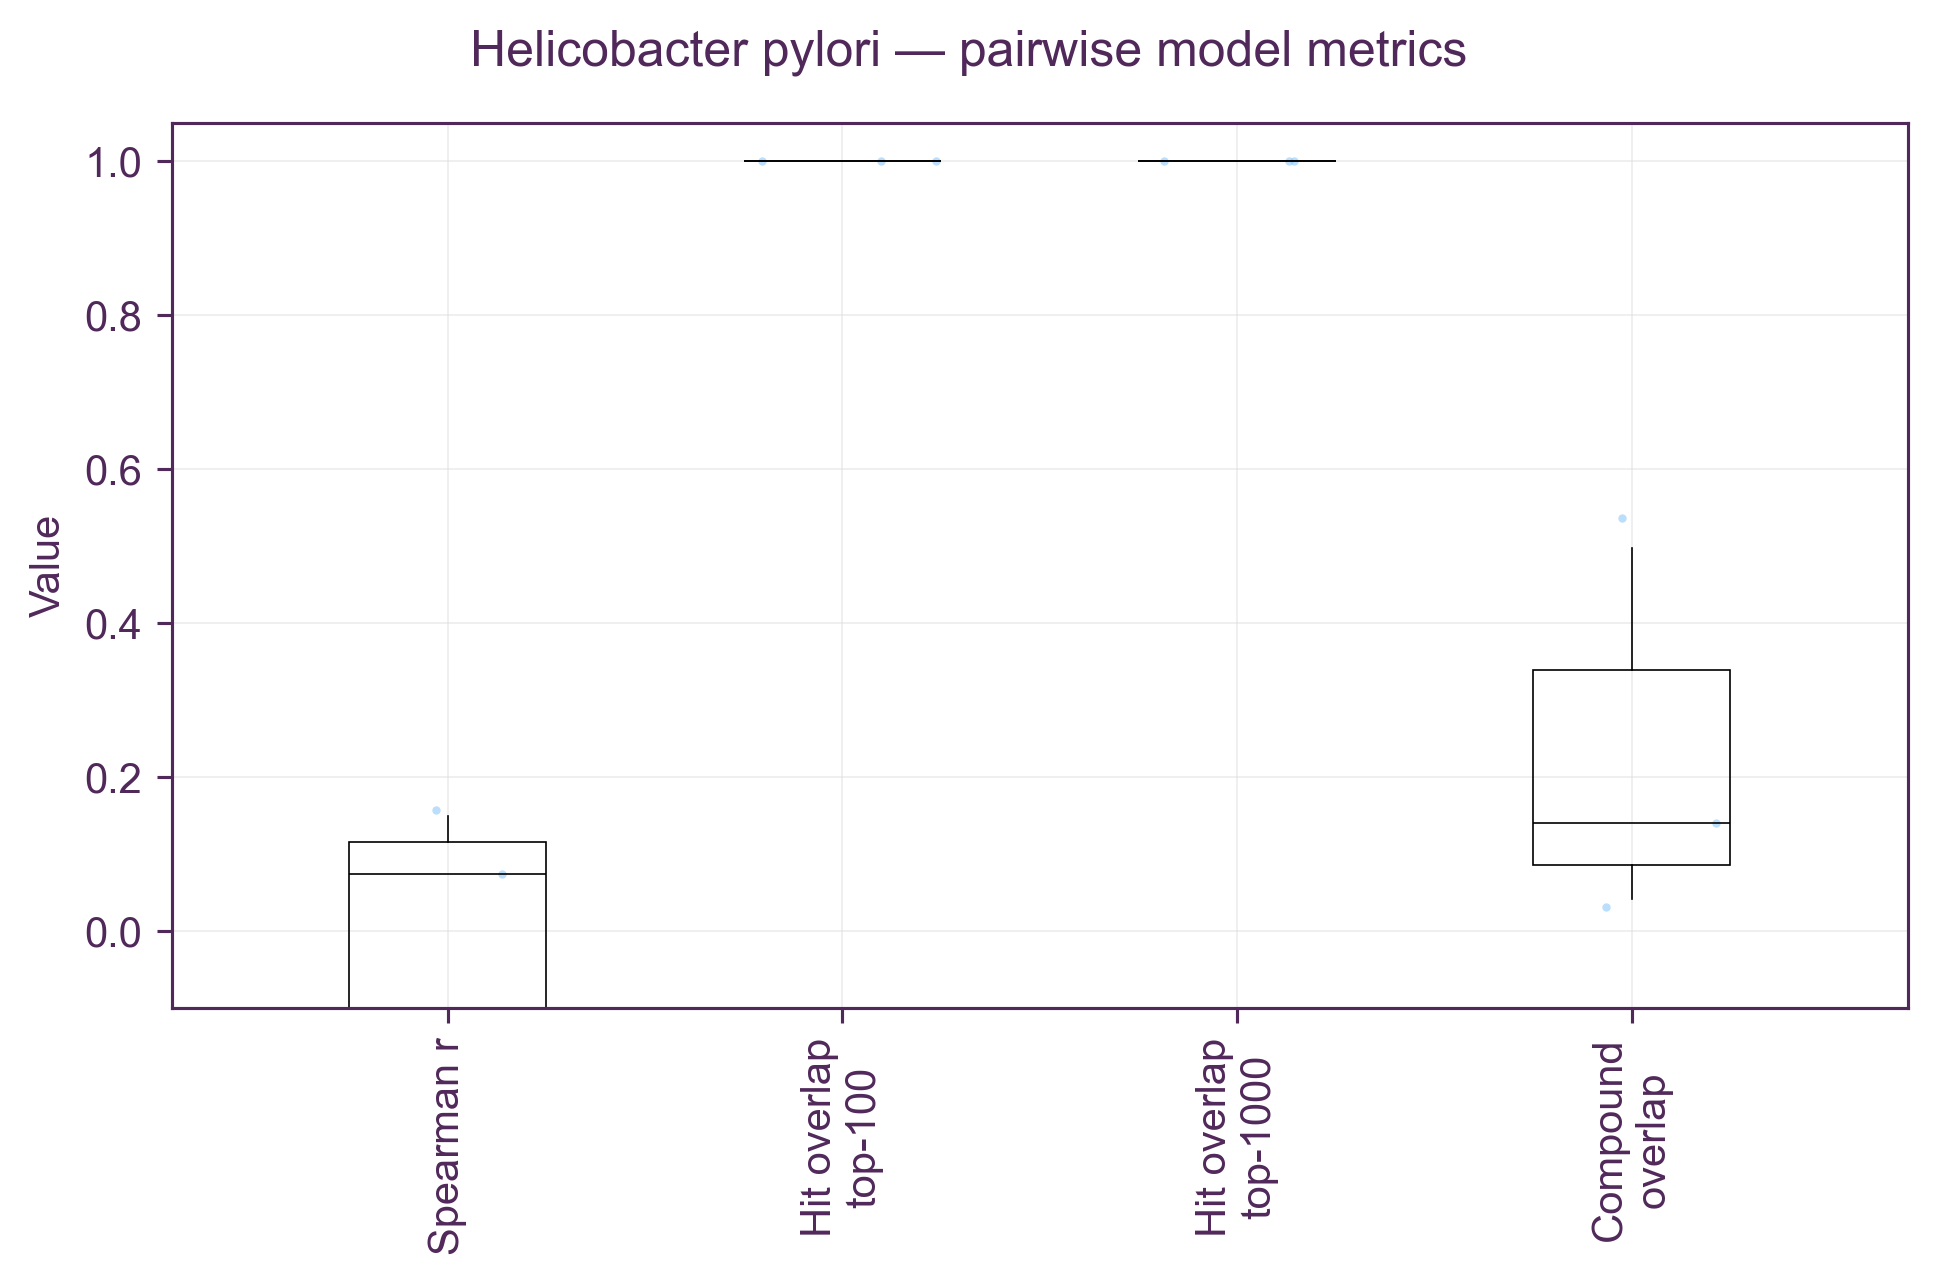

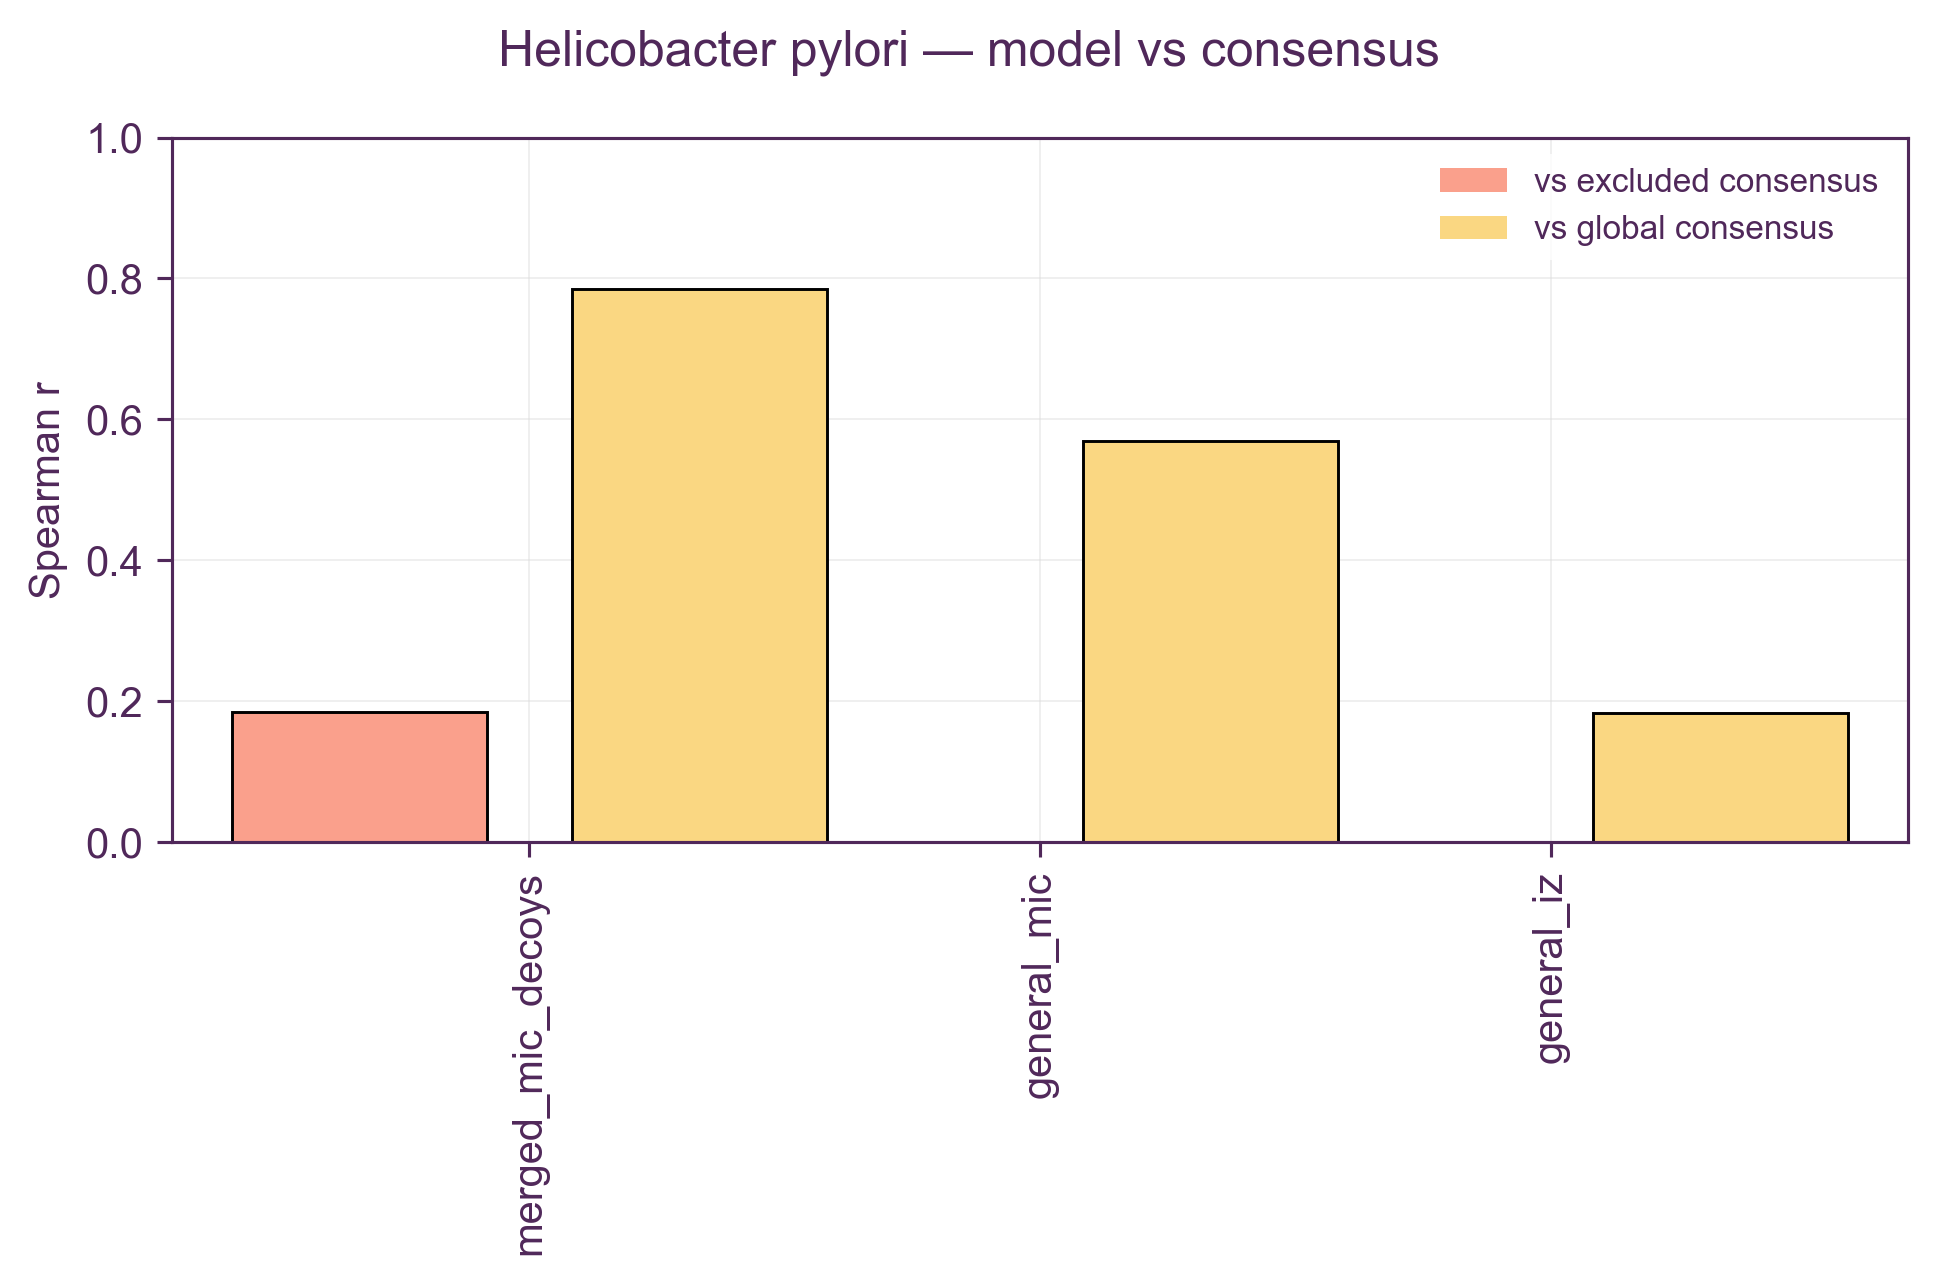

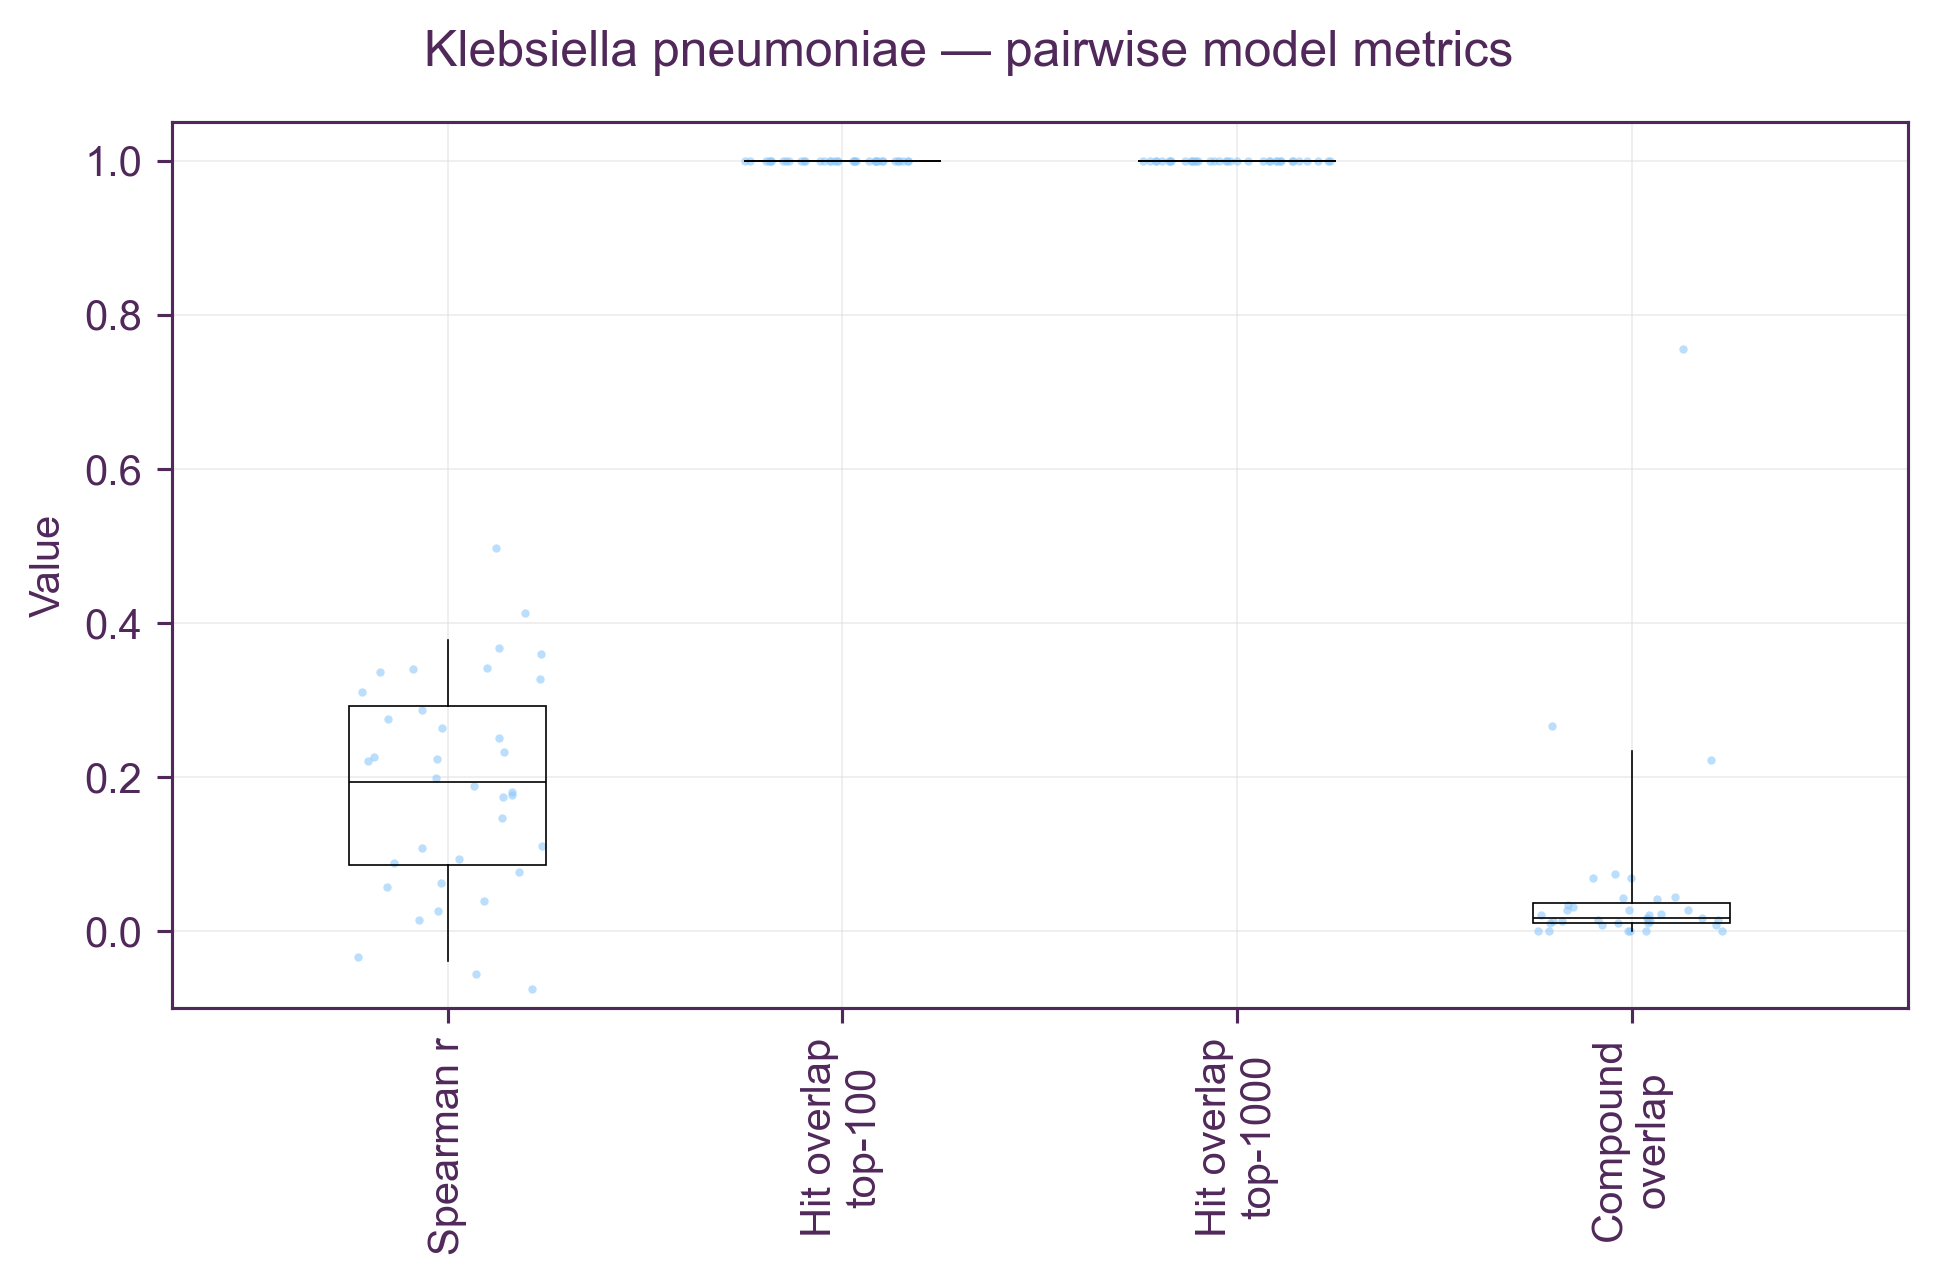

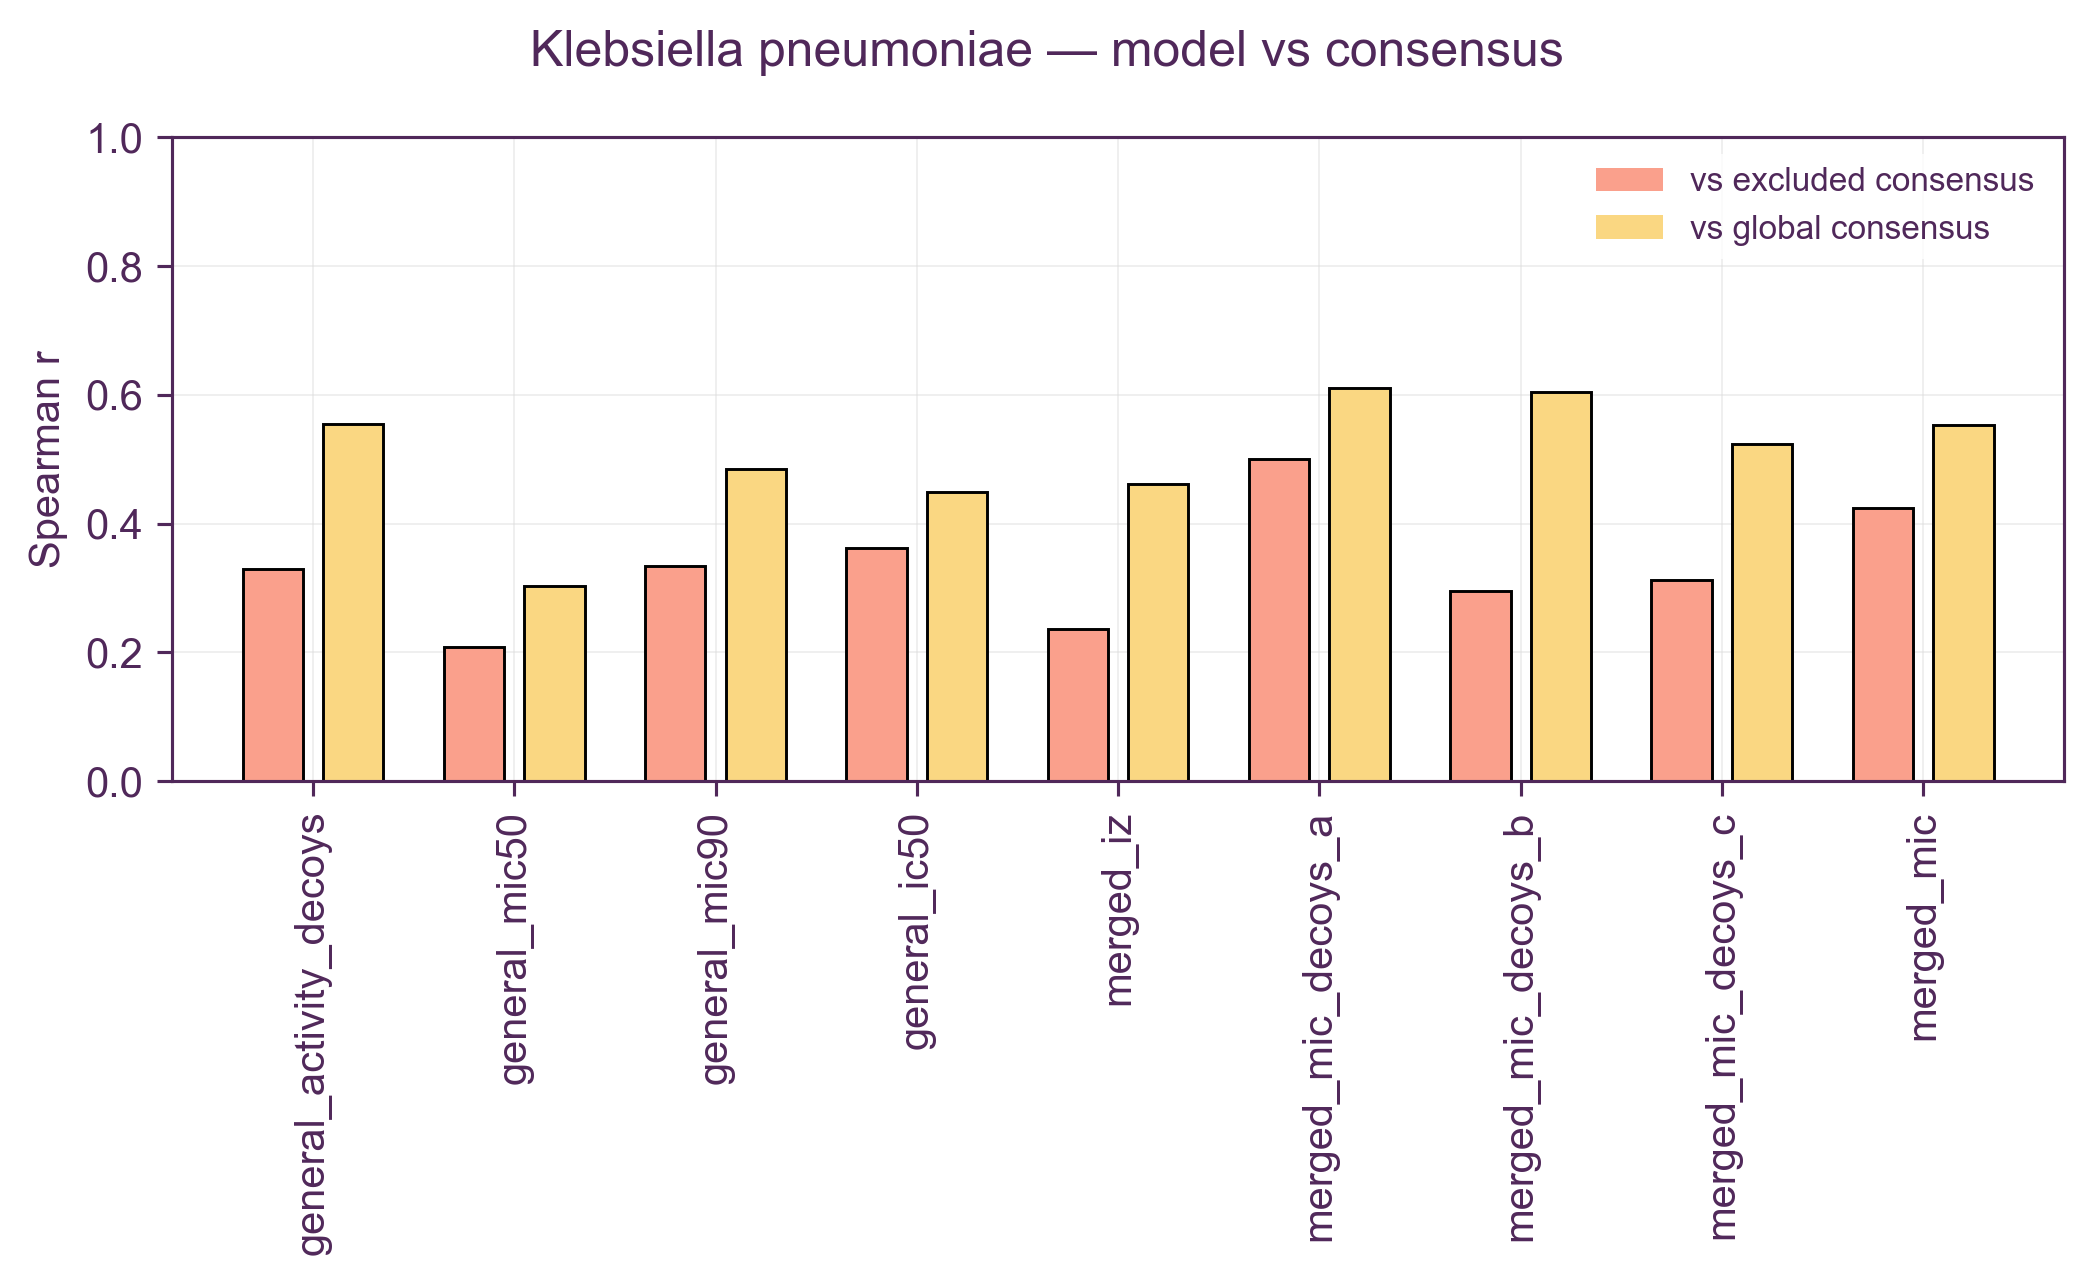

In [2]:
for pathogen in pathogens["code"]:

    print(f"Pathogen: {code_to_name[pathogen]}")

    src_models    = os.path.join(REPO_ROOT, "output", "results", "14_correlations", f"{pathogen}_models.csv")
    src_consensus = os.path.join(REPO_ROOT, "output", "results", "14_correlations", f"{pathogen}_consensus.csv")

    for src in (src_models, src_consensus):
        if not os.path.isfile(src) or os.path.getsize(src) == 0:
            print(f"  [SKIP] file not found or empty: {src}")
            break
    else:

        models_df  = pd.read_csv(src_models)
        corr_df    = pd.read_csv(src_consensus)

        # ── Figure 1: distribution of pairwise metrics (upper triangle of model×model matrix) ──
        metrics       = ["spearman", "hit_overlap_100", "hit_overlap_1000", "compound_overlap"]
        metric_labels = ["Spearman r", "Hit overlap\ntop-100", "Hit overlap\ntop-1000", "Compound\noverlap"]
        M = len(metrics)
        w_m = 0.25

        fig1, axs1 = stylia.create_figure(1, 1, width=0.5, height=0.33)
        fig1.suptitle(f"{code_to_name[pathogen]} — pairwise model metrics", fontsize=12)

        ax1 = axs1.next()
        ax1.set_ylabel("Value")
        ax1.set_ylim([-0.1, 1.05])
        ax1.set_xlim([-0.7, M - 0.3])

        rng = np.random.default_rng(42)
        for i, metric in enumerate(metrics):
            values = models_df[metric].dropna().values
            x_jitter = [i + rng.uniform(-w_m, w_m) for _ in values]
            ax1.scatter(x_jitter, values, color=pal.get(8)[4], s=4, alpha=0.6, lw=0)
            stats = dict(
                med=np.median(values),
                q1=np.percentile(values, 25),
                q3=np.percentile(values, 75),
                whislo=np.percentile(values, 5),
                whishi=np.percentile(values, 95),
                fliers=[],
            )
            bp = ax1.bxp([stats], positions=[i], widths=w_m * 2, patch_artist=True, showfliers=False)
            bp["boxes"][0].set_linewidth(0.4)
            bp["boxes"][0].set_facecolor("none")
            for element in ["whiskers", "caps", "medians"]:
                for line in bp[element]:
                    line.set_color("k")
                    line.set_linewidth(0.4)
                    if element == "caps":
                        line.set_linewidth(0)

        ax1.set_xticks(range(M))
        ax1.set_xlabel(None)
        ax1.set_xticklabels(metric_labels, rotation=90)

        # ── Figure 2: per-model correlation vs excluded and global consensus ──
        N = len(corr_df)
        width = max(0.5, N * 0.06)
        w     = min(0.35, max(0.2, 1.0 / N))

        fig2, axs2 = stylia.create_figure(1, 1, width=width, height=0.33)
        fig2.suptitle(f"{code_to_name[pathogen]} — model vs consensus", fontsize=12)

        ax2 = axs2.next()
        ax2.set_ylabel("Spearman r")
        ax2.set_ylim([0, 1])
        ax2.set_xlim([-0.7, N - 0.3])

        for i, row in corr_df.iterrows():
            ax2.bar(i - w, row["spearman_r_excluded"], width=w * 1.5, color=pal.get(8)[3], ec='k', lw=0.7)
            ax2.bar(i + w, row["spearman_r_global"],   width=w * 1.5, color=pal.get(2)[1], ec='k', lw=0.7)

        ax2.set_xticks(range(N))
        ax2.set_xlabel(None)
        ax2.set_xticklabels(corr_df["model"].tolist(), rotation=90)

        legend_patches = [
            mpatches.Patch(color=pal.get(8)[3], label="vs excluded consensus"),
            mpatches.Patch(color=pal.get(2)[1], label="vs global consensus"),
        ]
        ax2.legend(handles=legend_patches, fontsize=8)